# Human Face Emotion Detection Using CNN

## Dataset

In [1]:
!mkdir -p ./kaggle
!cp kaggle.json ~/.kaggle/

cp: cannot stat 'kaggle.json': No such file or directory


In [2]:
!kaggle datasets download -d msambare/fer2013

Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
100% 60.3M/60.3M [00:00<00:00, 151MB/s]



In [3]:
!unzip /content/fer2013.zip -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/train/sad/Training_65242339.jpg  
  inflating: /content/train/sad/Training_65267116.jpg  
  inflating: /content/train/sad/Training_65275626.jpg  
  inflating: /content/train/sad/Training_6529266.jpg  
  inflating: /content/train/sad/Training_65329617.jpg  
  inflating: /content/train/sad/Training_65338712.jpg  
  inflating: /content/train/sad/Training_65338797.jpg  
  inflating: /content/train/sad/Training_65387162.jpg  
  inflating: /content/train/sad/Training_65404494.jpg  
  inflating: /content/train/sad/Training_65426218.jpg  
  inflating: /content/train/sad/Training_65430136.jpg  
  inflating: /content/train/sad/Training_65437377.jpg  
  inflating: /content/train/sad/Training_6545735.jpg  
  inflating: /content/train/sad/Training_65463385.jpg  
  inflating: /content/train/sad/Training_65473985.jpg  
  inflating: /content/train/sad/Training_65502829.jpg  
  inflating: /content/train/sad/Training_65505359.jpg  

The data consists of 48x48 pixel grayscale images of faces. The faces have been automatically registered so that the face is more or less centred and occupies about the same amount of space in each image.

The task is to categorize each face based on the emotion shown in the facial expression into one of seven categories (0=Angry, 1=Disgust, 2=Fear, 3=Happy, 4=Sad, 5=Surprise, 6=Neutral).

## Directory

In [4]:
import os
project_name = 'Human_Emotion_Detection'

model_names = ['Custom_CNN', 'Custom_CNN_with_Augmentation', 'VGG16', 'ResNet50']

project_dir = os.path.join('/content/', project_name)
os.makedirs(project_dir)

In [5]:
for model in model_names:

  model_dir = os.path.join(project_dir, model)
  os.makedirs(model_dir, exist_ok=True)

## Packages

In [37]:
import os

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import tensorflow
from tensorflow import keras
from keras import regularizers
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger
from keras.layers import Dense, Conv2D, Flatten, Activation, BatchNormalization, Dropout, MaxPooling2D
from keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## Data Analysis

In [ ]:
# Data Cleaning

def data_cleaning(path):

  image_format = ['.jpg', '.jpeg', '.png']
  count = 0

  for root, dir, files in os.walk(path):

    for file in files:

      file_path = os.path.join(root, file)
      _, extension = os.path.splitext(file_path)

      if extension not in image_format:

        os.remove(file_path)
        count += 1

  return count

In [8]:
data_cleaning('/content/train')

0

In [9]:
data_cleaning('/content/test')

0

In [10]:
def count_images(path):

  count = {}

  for item in os.listdir(path):

    item_path = os.path.join(path, item)
    count[item] = len(os.listdir(item_path))

  return count

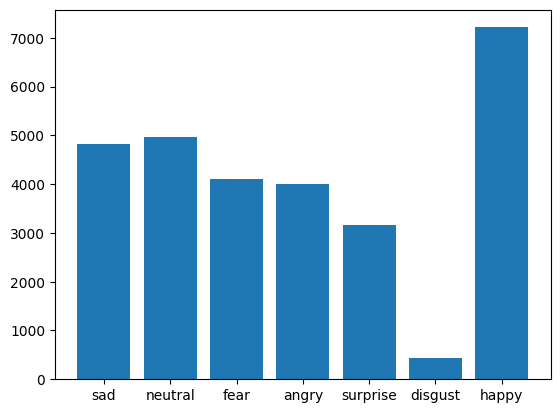

In [11]:
train_count = count_images('/content/train')

plt.bar(x=list(train_count), height=[train_count[x] for x in list(train_count)])
plt.show()

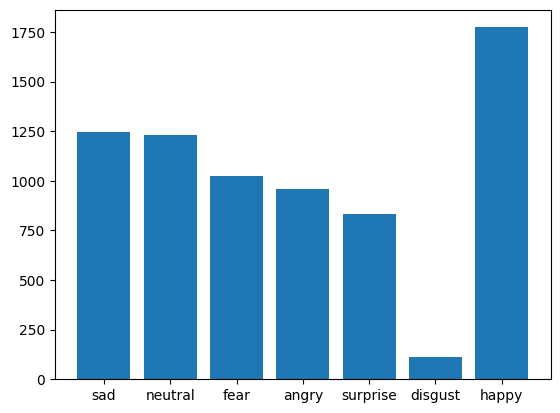

In [12]:
test_count = count_images('/content/test')

plt.bar(x=list(test_count), height=[test_count[x] for x in list(test_count)])
plt.show()

In [36]:
total_training_data = sum([train_count[x] for x in list(train_count)])
total_training_data

28709

### Emotions

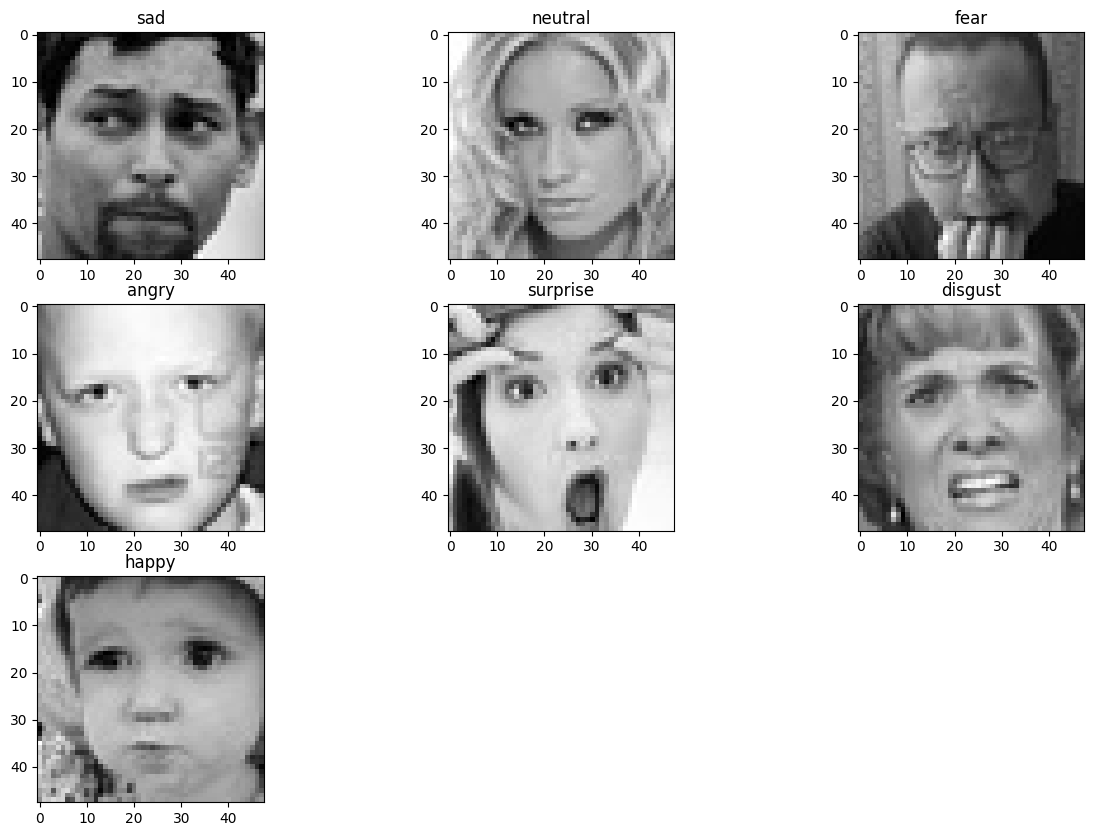

In [13]:
plt.figure(figsize=(15, 10))

i = 1

for dir in os.listdir('/content/train'):

  folders_path = os.path.join('/content/train', dir)
  img_path = os.path.join(folders_path, os.listdir(folders_path)[1])

  img = mpimg.imread(img_path)

  plt.subplot(3, 3, i)

  plt.imshow(img, cmap='gray')
  plt.title(dir)

  i+=1

In [14]:
img.shape

(48, 48)

## Custom CNN

In [15]:
train_dir = '/content/train'
test_dir = '/content/test'

img_width, img_height = 48, 48
batch_size = 64
classes = 7

In [16]:
data_generator = ImageDataGenerator(rescale=1.0/255.0, validation_split=0.2)

train_ds = data_generator.flow_from_directory(
    directory = train_dir,
    target_size = (img_width, img_height),
    color_mode = 'grayscale',
    batch_size = batch_size,
    class_mode = 'categorical',
    subset = 'training'
)

validation_ds = data_generator.flow_from_directory(
    directory = train_dir,
    target_size = (img_width, img_height),
    color_mode = 'grayscale',
    batch_size = batch_size,
    class_mode = 'categorical',
    subset = 'validation'
)

test_ds = data_generator.flow_from_directory(
    directory = test_dir,
    target_size = (img_width, img_height),
    color_mode = 'grayscale',
    batch_size = batch_size,
    class_mode = 'categorical'
)

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [17]:
train_ds.class_indices

{'angry': 0,
 'disgust': 1,
 'fear': 2,
 'happy': 3,
 'neutral': 4,
 'sad': 5,
 'surprise': 6}

In [18]:
test_ds.class_indices

{'angry': 0,
 'disgust': 1,
 'fear': 2,
 'happy': 3,
 'neutral': 4,
 'sad': 5,
 'surprise': 6}

In [19]:
validation_ds.class_indices

{'angry': 0,
 'disgust': 1,
 'fear': 2,
 'happy': 3,
 'neutral': 4,
 'sad': 5,
 'surprise': 6}

In [29]:
model = Sequential()

model.add(Conv2D(32, input_shape=(img_width, img_height, 1), padding='same', kernel_initializer='he_normal', kernel_size=(3, 3)))
model.add(Activation('relu'))
model.add(Conv2D(64, padding='same', kernel_size=(3, 3)))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2, 2))
model.add(Dropout(0.2))

model.add(Conv2D(128, kernel_regularizer=regularizers.l2(0.01), padding='same', kernel_size=(3, 3)))
model.add(Activation('relu'))
model.add(Conv2D(256, kernel_regularizer=regularizers.l2(0.01), kernel_size=(3, 3), padding='same'))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2, 2))
model.add(Dropout(0.2))

model.add(Conv2D(512, kernel_regularizer=regularizers.l2(0.01), padding='same', kernel_size=(3, 3)))
model.add(Activation('relu'))
model.add(Conv2D(512, kernel_regularizer=regularizers.l2(0.01), kernel_size=(3, 3), padding='same'))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2, 2))
model.add(Dropout(0.2))

model.add(Flatten())
model.add(Dense(1024, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.1))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.1))

model.add(Dense(classes, activation='softmax'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
model.compile(loss='categorical_crossentropy', metrics=['accuracy'], optimizer='adam')

In [31]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 24, 24, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 12, 12, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 12, 12, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │    18,875,392 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 23,339,015 (89.03 MB)

 Trainable params: 23,335,303 (89.02 MB)

 Non-trainable params: 3,712 (14.50 KB)



In [34]:
keras.utils.plot_model(
    model,
    to_file='/content/Human_Emotion_Detection/Custom_CNN/architecture.png',
    show_shapes=True,
    show_layer_names=True,
    show_layer_activations=True,
)

In [ ]:
# Call backs

early_stopping = EarlyStopping(
    monitor='val_loss',
    mode='auto',
    min_delta=0,
    patience=5,
    verbose=1,
    restore_best_weights=True
)

